In [10]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import gzip
import os
from functions import *
import matplotlib.pyplot as plt
from matplotlib import rc
import pyart
from matplotlib.ticker import MultipleLocator
import zstandard as zstd
import io

Settings

In [11]:
# lidar file to read in
des_file = "20241029204404_CAPPI_116.nc.zst"
# date/time info of lidar scans
des_year = des_file[:4]
des_mon = des_file[4:6]
des_day = des_file[6:8]
des_hour = des_file[8:10]
des_min = des_file[10:12]
des_sec = des_file[12:14]
# lidar system info
des_sys = "ARRC" # ARRC, WG100-L0AD00003JP, or WG100-L0AD00004JP
lidar_loc = "ARRC" # Hampton, VA or ARRC
# directory = f"/data/arrcwx/robbyfrost/lidar_obs/{des_sys}/{des_year}/{des_mon}/{des_day}/"
directory = f"/data/arrcwx/MetroWeather/{des_sys}/{des_year}/{des_mon}/{des_year}{des_mon}{des_day}/" 
# directory for saving figues
figdir = f"/home/robbyfrost/Analysis/TurbTor_Lidar/figures/{des_sys}/{des_year}/{des_mon}/{des_day}/"
os.makedirs(figdir, exist_ok=True)

# scan strategy info
des_elev = 5.
# snr threshold for masking out data
snr_cut = -10
# start and end azimuths for averaging
az_start, az_end = 293.925, 358.99

# full path to lidar file
file_path = directory + des_file
# read in compressed lidar file
with open(file_path, 'rb') as compressed_file:
    decompressor = zstd.ZstdDecompressor()
    # Decompress into memory
    decompressed_data = decompressor.decompress(compressed_file.read())
    # Create a file-like object from bytes
    file_like_obj = io.BytesIO(decompressed_data)
    # create xarray dataset
    ds = xr.open_dataset(file_like_obj, engine='h5netcdf')

# only include desired elevation
ds = ds.where(ds.elevation == des_elev, drop=True)
# filter out low snr on desired variables
good_snr = 10 * np.log10(ds.snr-1)
ds['dpl'] = ds.dpl.where(good_snr > snr_cut)
# ds['snr'] = ds.snr.where(good_snr > snr_cut)

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')

Extract arrays from lidar output

In [12]:
# account for range offset
range_offset = 1425 # meters
start_point = np.argmin(abs(ds.ranges[:,0].data-range_offset))+1
# scan dimensions
az = ds.azimuth.data# * -1 + 90
r = ds.ranges[start_point:,0].data - range_offset
el = ds.elevation.data
# radial velocity
vr = ds.dpl[:,0,start_point:].data * -1
vr_smoothed = xr.DataArray(vr, dims=("az","r"), coords={'az': az, 'r': r}).rolling(az=3,r=3).mean().values
# calculate vertical vorticity
vort_z = ( (vr[1:,:] - vr[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)
vort_z_resized = np.pad(vort_z, pad_width=((0, 1), (0, 0)), mode='constant', constant_values=np.nan)
vort_z_smoothed = ( (vr_smoothed[1:,:] - vr_smoothed[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)
# other observations
pwr = ds.pwr[:,0,start_point:].data * 100
snr = 10 * np.log10(ds.snr[:,0,start_point:].data - 1)
sw = ds.wth[:,0,start_point:].data
noise_level = ds.noise_level[:,0,start_point:].data
# power_spectra = ds.power_spectra[:,0,start_point:].data
doppler_velocity = ds.doppler_velocity.data
# lidar information
ob_method = ds.attrs['observation_method']
serial_number = ds.attrs['serial_number']
lat = ds.latitude.data
lon = ds.longitude.data
altitude = ds.altitude.data
# scan setting information
rpm_azimuth = ds.rpm_azimuth[start_point:].data
# scan time information
record_start_time = ds.start_time.data
start_time = ds.attrs['start_time'][11:19]
start_date = ds.attrs['start_time'][:10]
end_time = ds.attrs['end_time'][11:19]
end_date = ds.attrs['end_time'][:10]

Make Barnes grid

In [13]:
# put radial velocity data into pyart radar object
radar = pyart.testing.make_empty_ppi_radar(r.size, az.size, 1)
# Create metadata for the field
vr_field = {
    'data': vr,
    'long_name': 'Doppler velocity',
    'units': 'm/s',
    'standard_name': 'radial_velocity',
    'comments': 'Filtered Doppler velocity using SNR thresholding.'
}
vort_field = {
    'data': vort_z_resized,
    'long_name': 'Inferred Vertical Vorticity',
    'units': 'm/s',
    'standard_name': 'vort_z',
    'comments': 'Inferred vertical vorticity from radial velocity'
}
# Add the field to the radar object
radar.add_field('vr', vr_field)
radar.add_field('vort_z', vort_field)
radar.azimuth['data'] = az
radar.range['data'] = r

# Barnes Analysis
delx, dely = 50, 50
Lx, Ly = 17500, 20000
grid_barnes = pyart.map.grid_from_radars(
    radar,
    grid_shape=(1, Ly//dely, Lx//delx),
    gridding_algo = 'map_gates_to_grid',
    weighting_function = 'barnes2',
    # gatefilters = gfilter,
    grid_limits=(
        (0.0, 0.0),
        (-10000.0, 10000.0),
        (-10000.0, 7500.0),
    ),
)

# retrieve u and v
vr_grid = grid_barnes.fields['vr']['data'][0]
# Extract x and y grid coordinates
x = grid_barnes.x['data']  # Grid x-coordinates (meters)
y = grid_barnes.y['data']  # Grid y-coordinates (meters)
# Create 2D coordinate arrays
x_grid, y_grid = np.meshgrid(x, y)
# Calculate azimuth angle at each grid point (radians)
phi_grid = np.arctan2(y_grid, x_grid)
# Compute Cartesian velocity components
u_grid = -vr_grid * np.sin(phi_grid)
v_grid = -vr_grid * np.cos(phi_grid)
# Create metadata for u and v fields
u_field = {
    'data': u_grid[np.newaxis,:,:],
    'long_name': 'Zonal velocity',
    'units': 'm/s',
    'standard_name': 'eastward_velocity',
    'comments': 'Computed from radial velocity using azimuth angle.'
}
v_field = {
    'data': v_grid[np.newaxis,:,:],
    'long_name': 'Meridional velocity',
    'units': 'm/s',
    'standard_name': 'northward_velocity',
    'comments': 'Computed from radial velocity using azimuth angle.'
}
# Add fields to the grid object
grid_barnes.add_field('u', u_field)
grid_barnes.add_field('v', v_field)

# calculate vertical vorticity with cartesian wind
u = grid_barnes.fields['u']['data']
v = grid_barnes.fields['v']['data']
dudy = np.gradient(u, axis=1) / dely
dvdx = np.gradient(v, axis=2) / delx
vort_z_barnes = dvdx - dudy

/tmp/ipykernel_837916/2420956458.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vr,


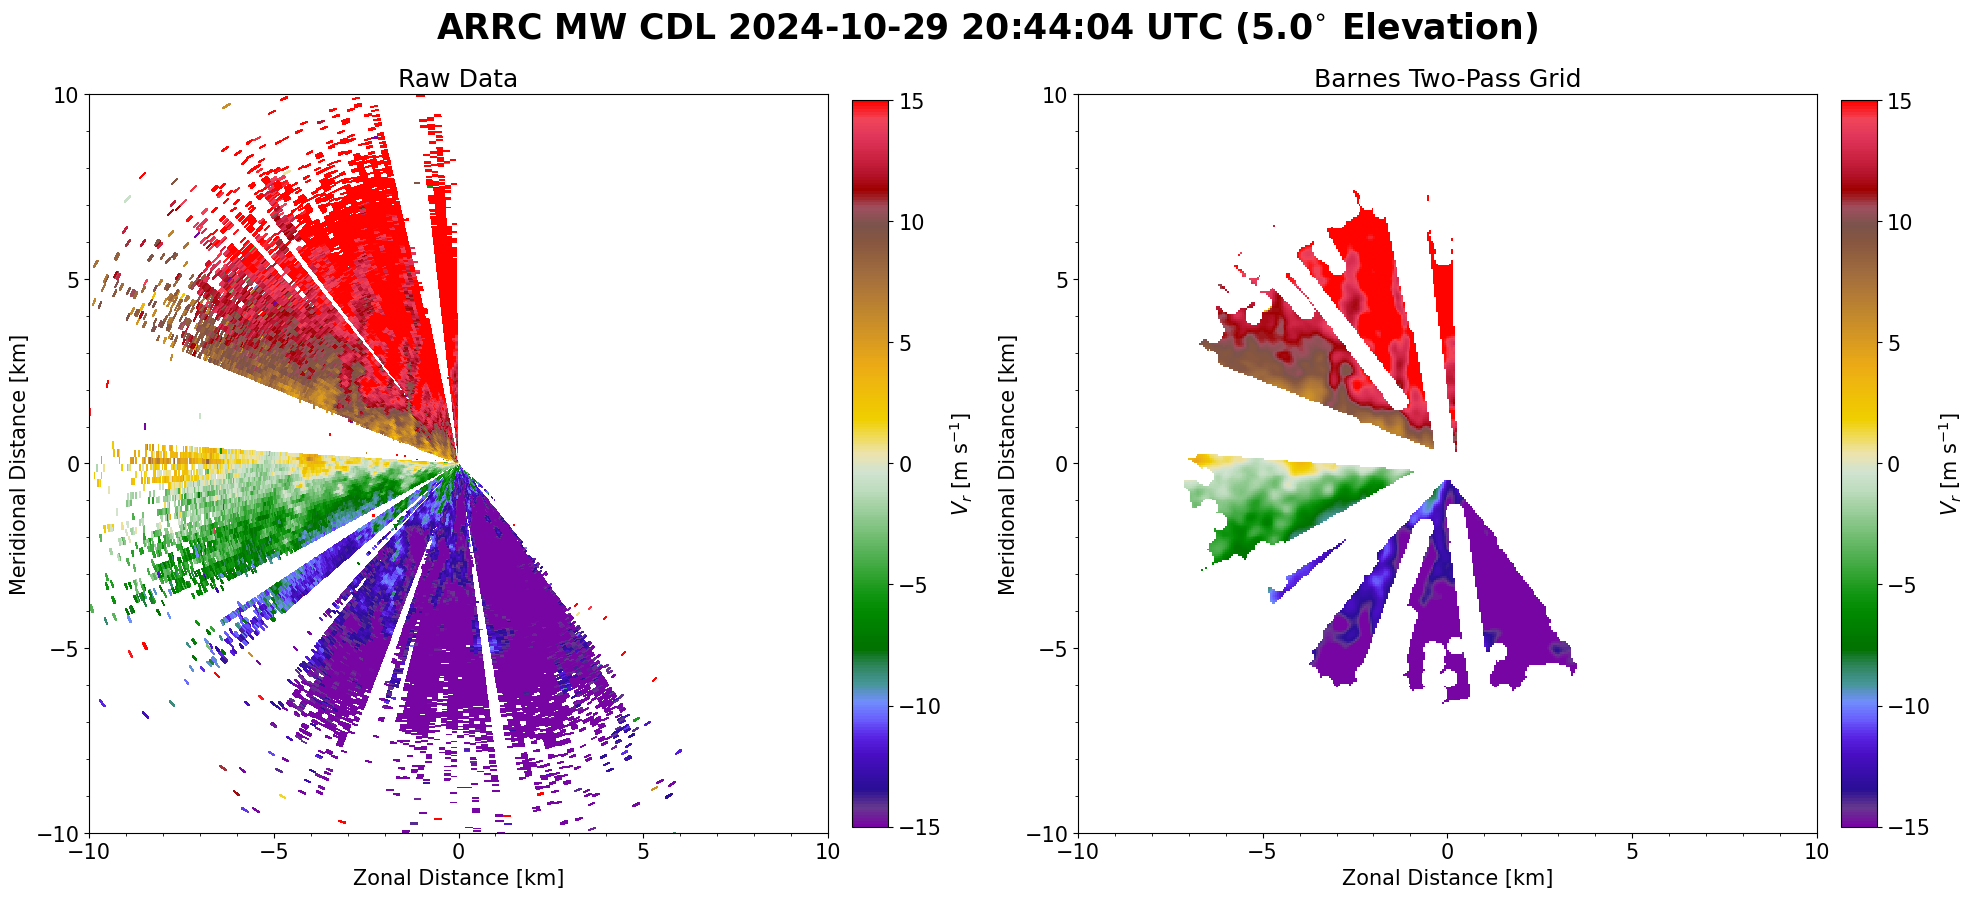

In [14]:
rmax = 10 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -15, 15
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vr,
                        vmin=vmin, vmax=vmax,
                        cmap="pyart_Carbone42")
ax[0].set_title("Raw Data")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$V_r$ [m s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.0001, 5))

vmin, vmax = -15, 15
XX, YY = np.meshgrid(grid_barnes.x["data"], grid_barnes.y["data"])
pcm2 = ax[1].pcolormesh(XX/1e3, YY/1e3, grid_barnes.fields['vr']['data'][0],
                        vmin=vmin, vmax=vmax,
                        cmap="pyart_Carbone42")
ax[1].set_title("Barnes Two-Pass Grid")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("$V_r$ [m s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.001, 5))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MW CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()

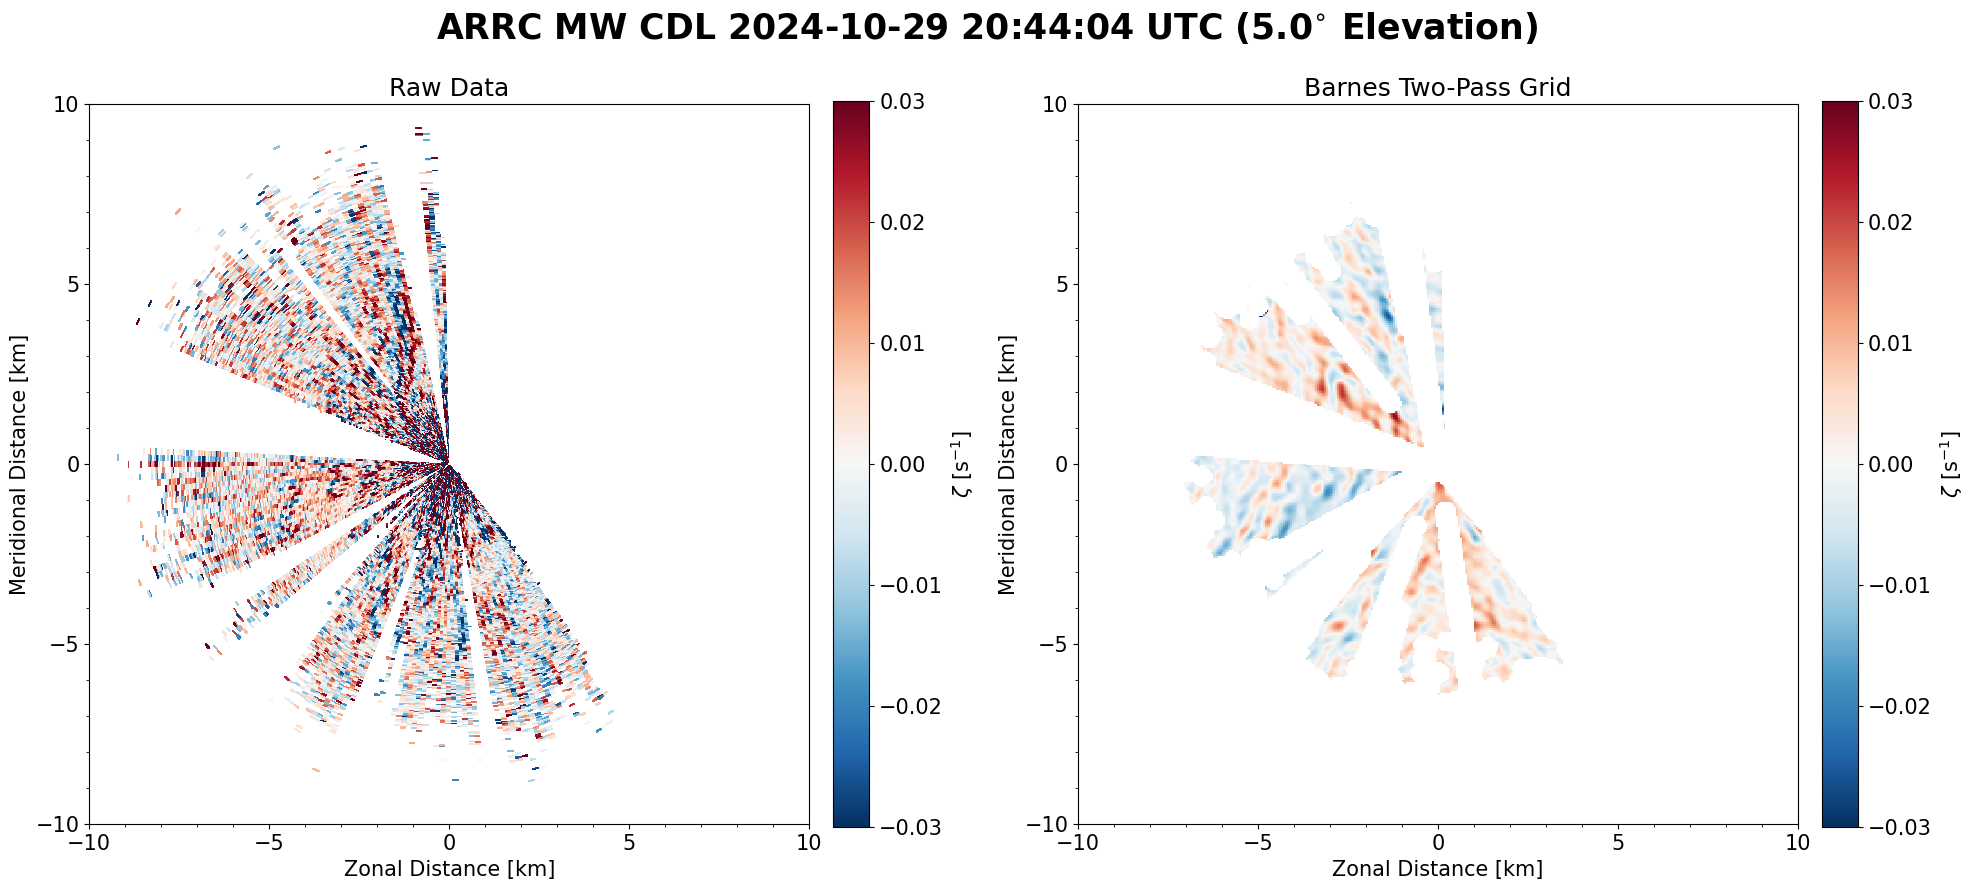

In [17]:
rmax = 10 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -0.03, 0.03
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[0].set_title("Raw Data")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$\\zeta$ [s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.0001, 0.01))

vmin, vmax = -0.03, 0.03
XX, YY = np.meshgrid(grid_barnes.x["data"], grid_barnes.y["data"])
pcm2 = ax[1].pcolormesh(XX/1e3, YY/1e3, vort_z_barnes[0],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[1].set_title("Barnes Two-Pass Grid")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("$\\zeta$ [s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.0001, 0.01))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MW CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()

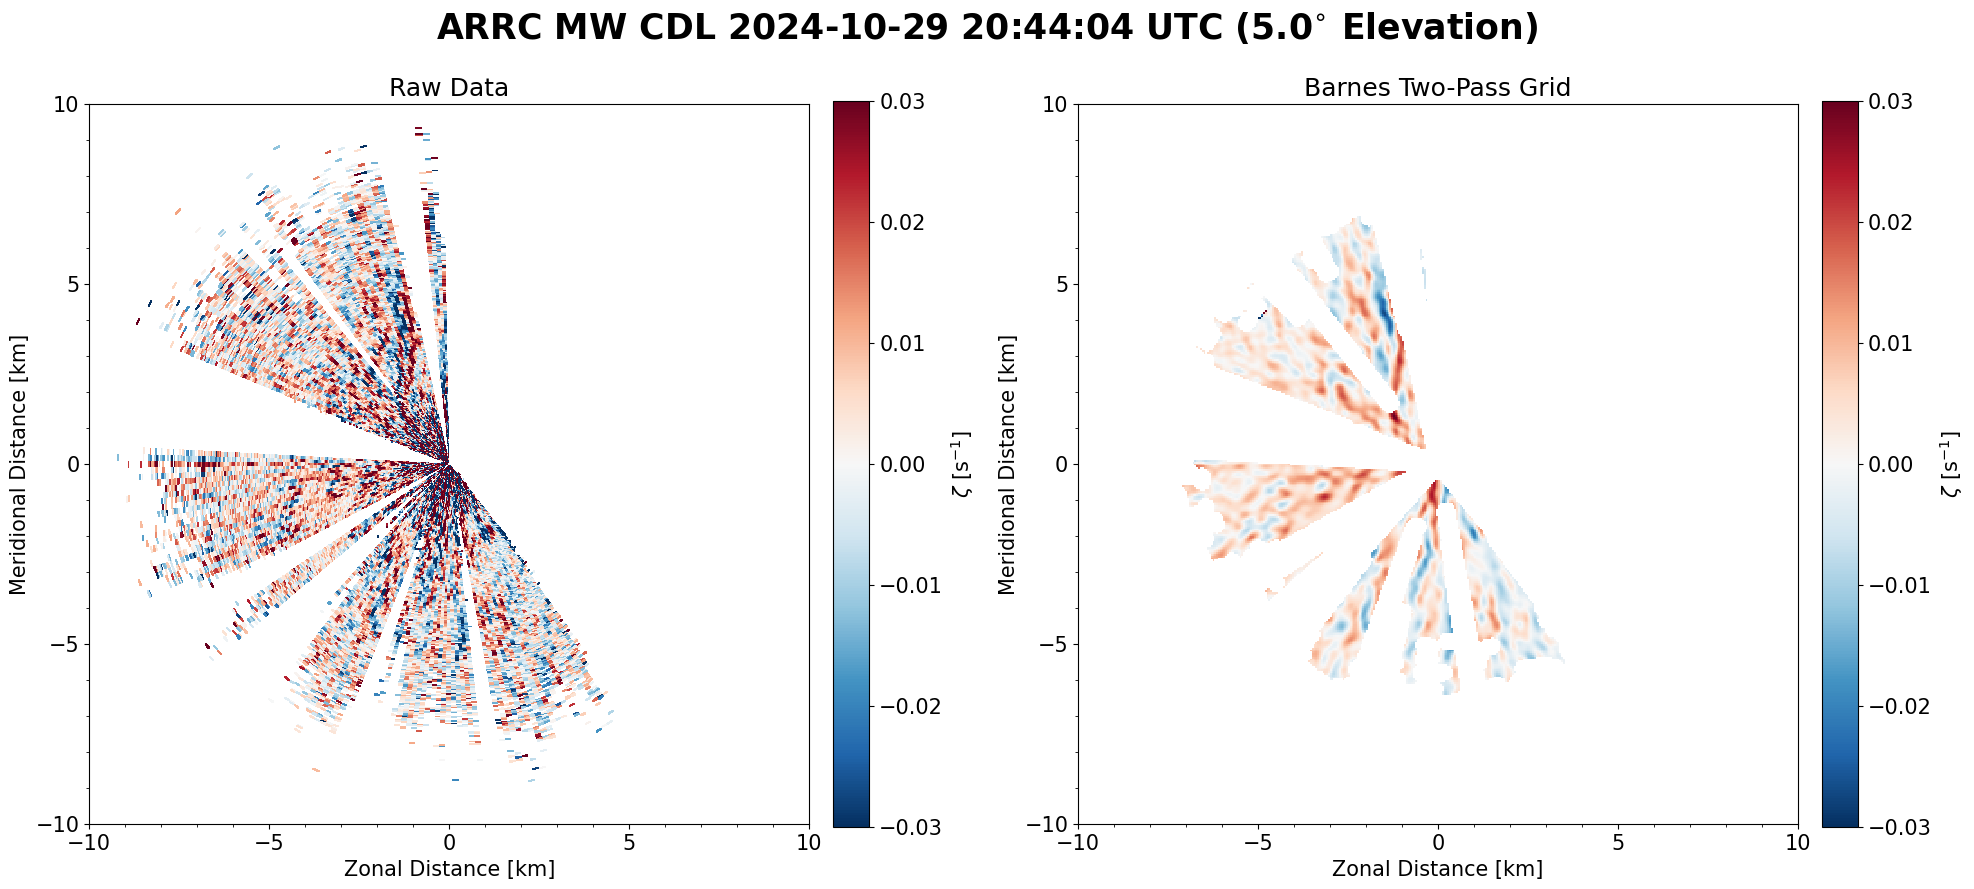

In [16]:
rmax = 10 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -0.03, 0.03
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[0].set_title("Raw Data")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$\\zeta$ [s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.0001, 0.01))

vmin, vmax = -0.03, 0.03
XX, YY = np.meshgrid(grid_barnes.x["data"], grid_barnes.y["data"])
pcm2 = ax[1].pcolormesh(XX/1e3, YY/1e3, grid_barnes.fields['vort_z']['data'][0],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[1].set_title("Barnes Two-Pass Grid")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("$\\zeta$ [s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.0001, 0.01))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MW CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()